In [1]:
import numpy as np
import matplotlib.pyplot as plt
from fno_definitions import*
import torch
from FFEM_building_blocks import Mesh

# Automatic generation of source functions and the Poisson solution algorithm
# For the moment I keep a small number of modes and max frequencies, 
# otherwise the dimensionality of the training dataset rises too quickly and the training becomes mofre complicated
# I use the same function in the create_training_dataset.py file

def generate_source_function(num_modes:int=3, max_freq:int=4, max_amplitude = 1.):
    """
    Uses a random truncated Fourier series with random amplitudes
    """
    # first pick some frequencies
    kx = np.random.randint(-max_freq-1, max_freq + 1, size=num_modes)
    ky = np.random.randint(-max_freq-1, max_freq + 1, size=num_modes)

    # now draw the corresponding amplitudes and phases
    amplitudes = np.random.uniform(-max_amplitude, max_amplitude, size=num_modes)
    phases = np.random.uniform(0, 2 * np.pi, size=num_modes)

    def source_function(x, y):
        result = 0
        for i in range(num_modes):
            result += amplitudes[i] * np.cos(kx[i] * x + ky[i] * y + phases[i])
        return result

    return source_function

# Literature

1) FNO for differential equations (original paper)
https://arxiv.org/abs/2010.08895

2) General introduction, complete
https://arxiv.org/abs/2512.01421v2, see NeuralOperator 2.0.0 library

# Minor stuff and trials (visualizing spectral interpolation)

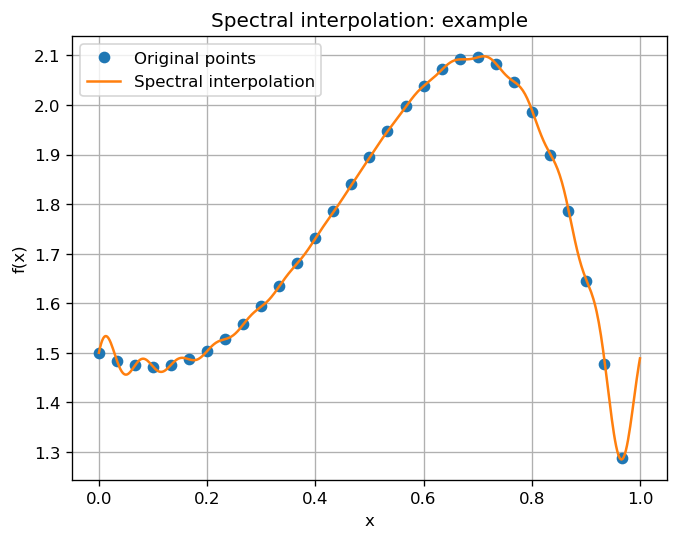

In [2]:
# test: spectral interpolation of 1d vector

def spectral_interpolation(signal: torch.tensor, M: int) -> torch.Tensor:

    """Gives the spectral interpolation of a 1d array on M points. Following 2), page 16"""
    N = len(signal) 
    fft_coeffs = torch.fft.fft(signal)
    pos_freqs = fft_coeffs[:N//2 + 1]
    neg_freqs = fft_coeffs[N//2 + 1:]

    fft_coeffs_padded = torch.cat([pos_freqs, torch.zeros(M - N), neg_freqs])

    return (torch.fft.ifft(fft_coeffs_padded).real)*M/N # the interpolated signal, scale by M/N to preserve energy


f = lambda x: torch.sin(3*x**2) + 0.5*torch.cos(torch.sqrt(x)) + 1.0 - x/3.

N = 30
xx = torch.linspace(0, 1, N+1)[:-1] # data x_n, n from 0 to N-1 

M_eval = 500

plt.figure(dpi = 120)
plt.title('Spectral interpolation: example')
plt.grid()
plt.xlabel('x')
plt.ylabel('f(х)')
plt.plot(xx, f(xx), 'o', label = 'Original points')
plt.plot(torch.linspace(0, 1, M_eval), spectral_interpolation(f(xx), M_eval), label = 'Spectral interpolation')
plt.legend()
plt.show()

# First FNO trial (with definition from `fno_definitions.py`)

In [3]:
# a 64x64 grid with 2000 test functions nearly eats up all of my computer's RAM (16BG)
# for the moment trying on a smaller 48x48 grid with 1000 test functions

# start with something reasonably small
fno_trial = FNO_v1(n_modes = [8,8], hidden_dimension = 24, lr = 1e-3)

# REMARK: note that compared to the way I set up the deepONets, here the X and Y (input and output) arrays are kept 2d and not flattened with .ravel().
# this is because I need to distinguish the two directions for the 2d fft to be applicable

# the solutions in the dataset are computed on the [-1, 1] 2d-square, on a 64x64 grid
fno_trial.fit_from_npz('data/dataset_for_fno.npz', 30)

# mini-batching greatly help convergence towards non-uniform results

Y std across samples: 0.8486582636833191
Y std across points:  0.4906511902809143


/Users/filippo/Desktop/neural_operators/fno_definitions.py:104: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [32, 48, 25, 24]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  fft_x = torch.fft.rfftn(x, dim=(-3, -2))
/Users/filippo/Desktop/neural_operators/fno_definitions.py:113: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [32, 48, 48, 24]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements

Epoch [10/30], Loss: 1.4804, Loss eval: 1.4950


/Users/filippo/Desktop/neural_operators/fno_definitions.py:104: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [4000, 48, 25, 24]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  fft_x = torch.fft.rfftn(x, dim=(-3, -2))
/Users/filippo/Desktop/neural_operators/fno_definitions.py:113: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [4000, 48, 48, 24]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elem

prediction std across samples: 0.44694000482559204
prediction std across points: 0.3246838450431824
Epoch [20/30], Loss: 1.4732, Loss eval: 1.4931
prediction std across samples: 0.44105270504951477
prediction std across points: 0.3212786316871643
Epoch [30/30], Loss: 1.4662, Loss eval: 1.4887
prediction std across samples: 0.4444235861301422
prediction std across points: 0.32383638620376587


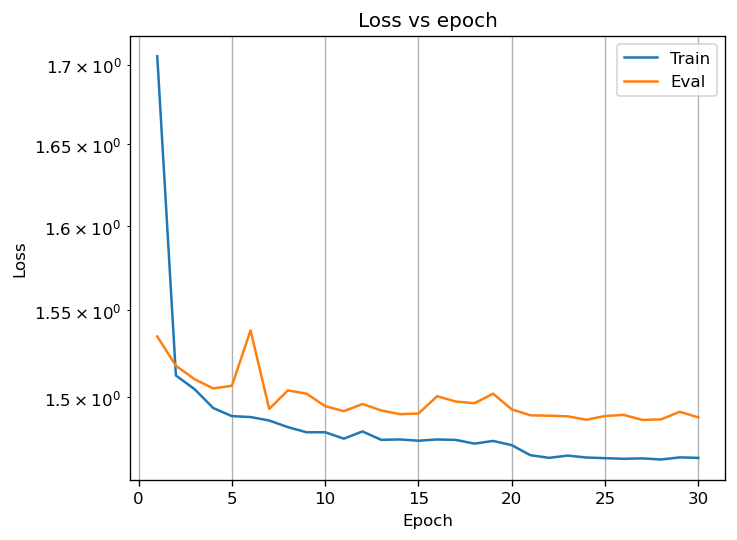

/var/folders/59/t4572hz13tg2y_6ql18g7cvw0000gn/T/ipykernel_33066/3426932002.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


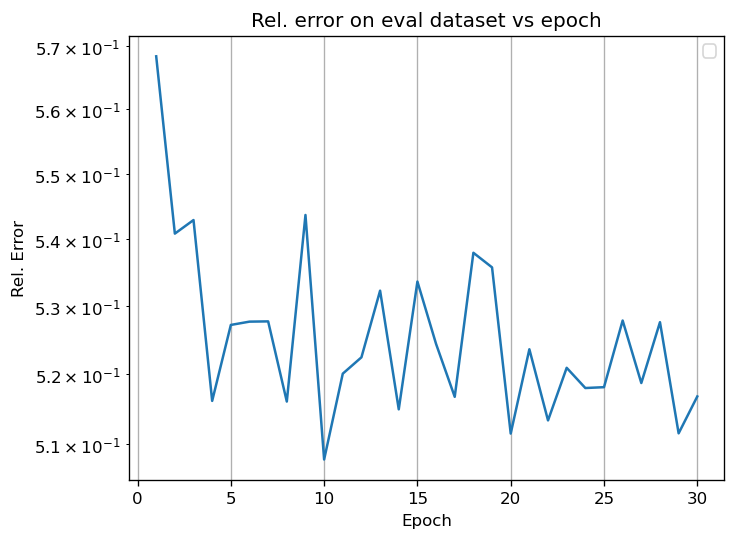

In [5]:
plt.figure(dpi = 120)
plt.title("Loss vs epoch")
plt.xlabel('Epoch')
plt.ylabel("Loss")
plt.semilogy(fno_trial.epochs, fno_trial.losses, label = "Train")
plt.semilogy(fno_trial.epochs, fno_trial.losses_eval, label = "Eval")
plt.legend()
plt.grid()
plt.show()

plt.figure(dpi = 120)
plt.title("Rel. error on eval dataset vs epoch")
plt.xlabel('Epoch')
plt.ylabel("Rel. Error")
plt.semilogy(fno_trial.epochs, fno_trial.rel_errors_eval)
plt.legend()
plt.grid()
plt.show()

**Problem: overfitting**, and in any case (I tested different configs and different training hyperparameters, with and without data normalization), the relative error on the training dataset seems to basically always converge to 0.4

Mass matrix initialization completed
Stiffness matrix initialization completed


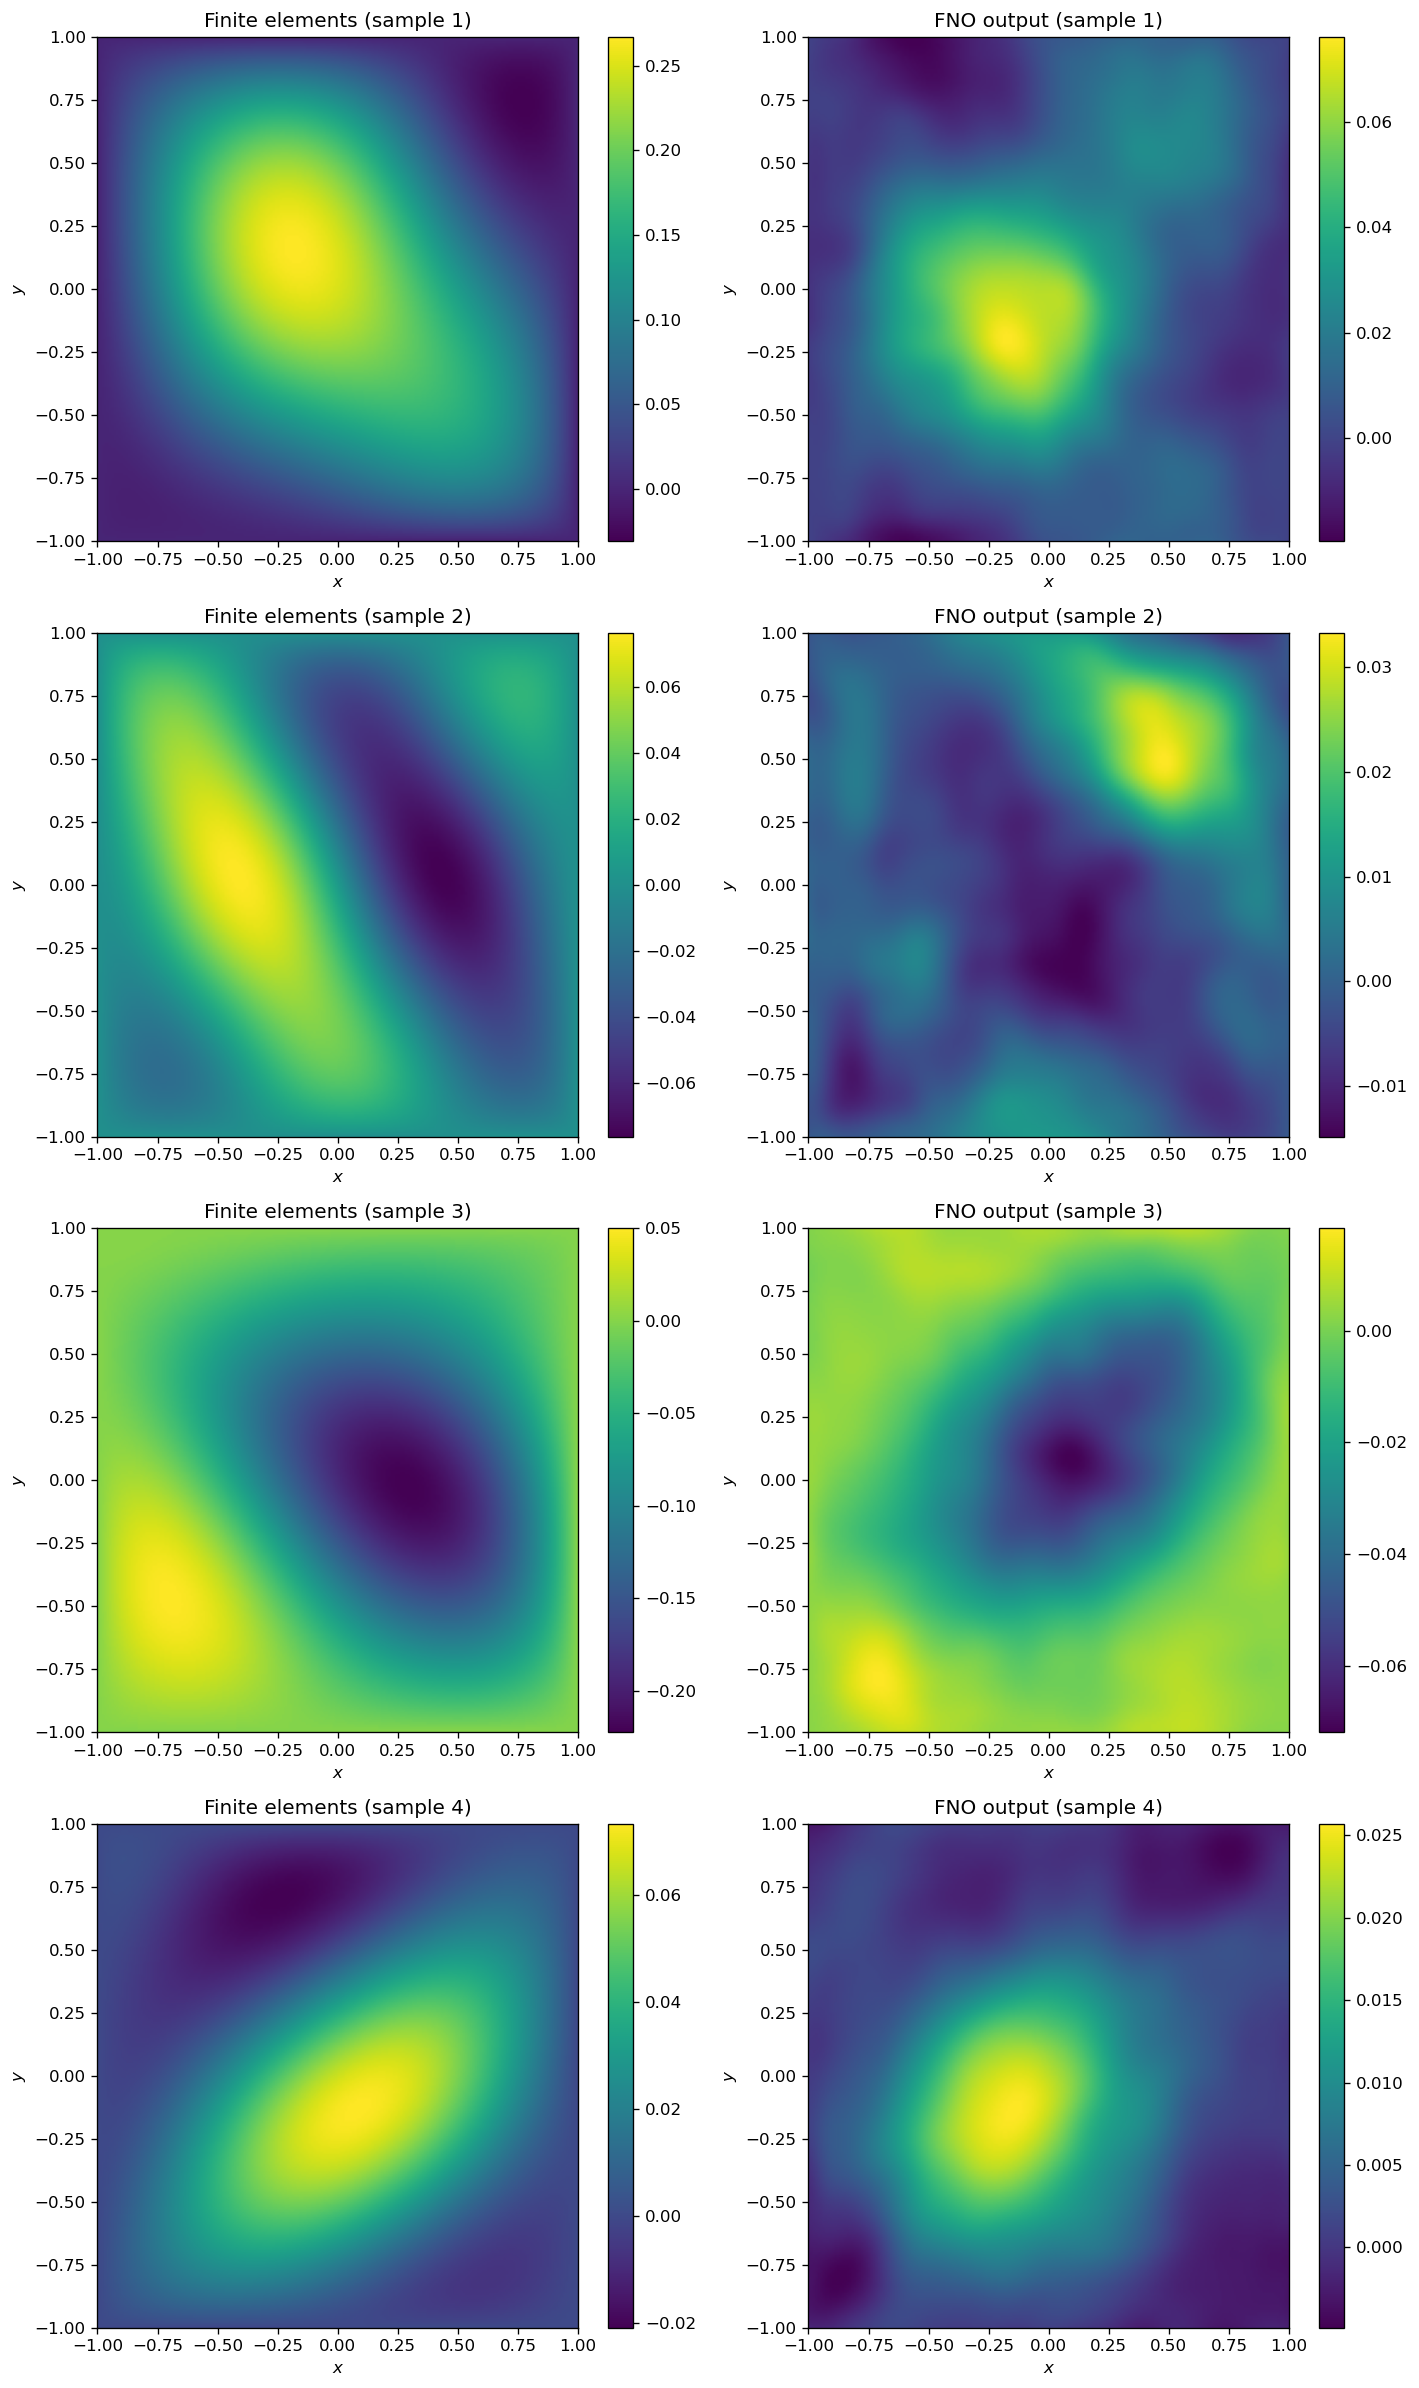

In [8]:
# now test visually on 4 randomly generated functions

x = np.linspace(-1, 1, 200)
y = np.linspace(-1, 1, 200)
mymesh = Mesh(x, y, verbose=True)
mymesh.build_mass_matrix()
mymesh.build_stiffness_matrix()

X, Y = np.meshgrid(x, y, indexing="ij")
diri = lambda x, y: 0

N_test = 4
fig, axes = plt.subplots(N_test, 2, figsize=(12, 5 * N_test), dpi=120)

for i in range(N_test):
    func = generate_source_function()

    res_finite_elements = mymesh.run_simulation_poisson_dirichlet(func, diri)
    result_fno = fno_trial.map_function_to_output_at_points(func, X, Y)

    im0 = axes[i, 0].imshow(res_finite_elements, cmap='viridis', origin='lower', aspect='auto', extent=[x.min(), x.max(), y.min(), y.max()])
    axes[i, 0].set_title(f'Finite elements (sample {i+1})')
    axes[i, 0].set_xlabel('$x$')
    axes[i, 0].set_ylabel('$y$')
    fig.colorbar(im0, ax=axes[i, 0])

    im1 = axes[i, 1].imshow(result_fno, cmap='viridis', origin='lower', aspect='auto', extent=[x.min(), x.max(), y.min(), y.max()])
    axes[i, 1].set_title(f'FNO output (sample {i+1})')
    axes[i, 1].set_xlabel('$x$')
    axes[i, 1].set_ylabel('$y$')
    fig.colorbar(im1, ax=axes[i, 1])

plt.tight_layout()
plt.show()

**Comments**

- results for a test function are usually (not always) vaguely reminiscent of the expected result, but still quite far away 
- spectral oscillations quite evident at 100 epochs, much less at 25 epochs. sign of overtraining
- so far only 100 iterations (otherwise just overtrainig). need to fix hyperparameters to go beyond

# Trying with FNO from neuralop.models (NeuralOperator library)

note here that the data structure is (f,x,y) - in my own model I use (x,y,f)

https://github.com/neuraloperator/neuraloperator

/opt/homebrew/anaconda3/lib/python3.13/site-packages/torch/nn/modules/module.py:1790: UserWarning: FNO.forward() received unexpected keyword arguments: ['y']. These arguments will be ignored.
  return forward_call(*args, **kwargs)


Raw outputs of shape torch.Size([16, 1, 48, 48])
[0] time=63.20, avg_loss=0.0002, train_err=0.0026


/Users/filippo/neuraloperator/neuralop/training/trainer.py:581: UserWarning: LpLoss.__call__() received unexpected keyword arguments: ['x']. These arguments will be ignored.
  val_loss = loss(out, **sample)
/Users/filippo/neuraloperator/neuralop/training/trainer.py:581: UserWarning: H1Loss.__call__() received unexpected keyword arguments: ['x']. These arguments will be ignored.
  val_loss = loss(out, **sample)


Eval: test_l2=0.9948, test_h1=1.0330
[3] time=63.04, avg_loss=0.0001, train_err=0.0014
Eval: test_l2=0.8492, test_h1=0.8173
[6] time=62.11, avg_loss=0.0001, train_err=0.0013
Eval: test_l2=0.7986, test_h1=0.7848
[9] time=63.77, avg_loss=0.0001, train_err=0.0013
Eval: test_l2=0.8769, test_h1=0.7750
[12] time=70.04, avg_loss=0.0001, train_err=0.0013
Eval: test_l2=0.7933, test_h1=0.7658
[15] time=75.47, avg_loss=0.0001, train_err=0.0013
Eval: test_l2=0.7917, test_h1=0.7652
[18] time=94.87, avg_loss=0.0001, train_err=0.0013
Eval: test_l2=0.8034, test_h1=0.7690
[21] time=64.12, avg_loss=0.0001, train_err=0.0013
Eval: test_l2=0.7925, test_h1=0.7583
[24] time=64.18, avg_loss=0.0001, train_err=0.0013
Eval: test_l2=0.7949, test_h1=0.7589
[27] time=63.83, avg_loss=0.0001, train_err=0.0013
Eval: test_l2=0.7902, test_h1=0.7576


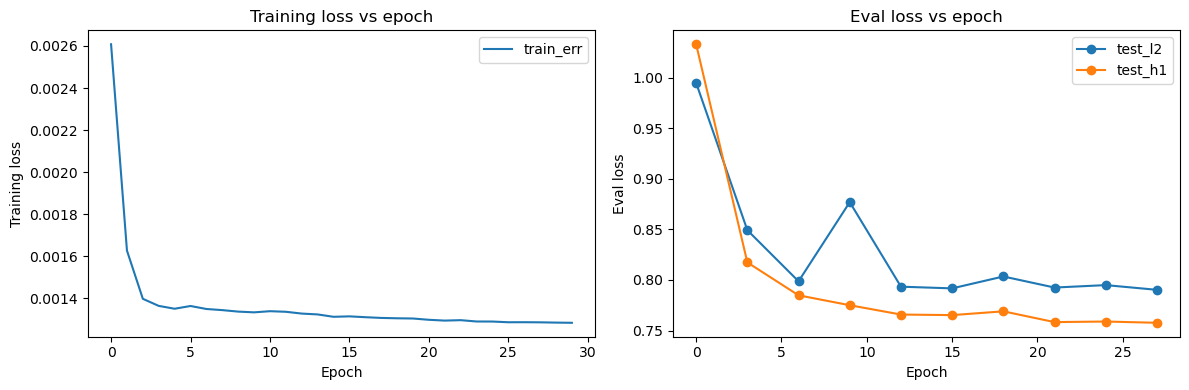

In [6]:
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os
from neuralop.models import FNO
from neuralop import Trainer
from neuralop.training import AdamW
from neuralop import LpLoss, H1Loss
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1" # need this for CPU fallback if mps support for somme fft-related operations is incomplete
from neuralop.data.datasets.tensor_dataset import TensorDataset

#device = torch.device("mps" if torch.backends.mps.is_available() else "cpu") # "mps" gives issues in backward. need to use "cpu"
device = torch.device("cpu")

# first load the training an test data
train_data = torch.load("data/poisson_train_48.pt")
test_data = torch.load("data/poisson_test_48.pt")


# define the train and test dataset with TensorDataset from the neuralop library
# neuralop expects each batch to be a dictionary with keys 'x', 'y'
train_dataset = TensorDataset(x=train_data['x'], y=train_data['y'])
test_dataset  = TensorDataset(x=test_data['x'], y=test_data['y'])

# define the train and test loaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)

# define the model
model = FNO(n_modes=(16, 16), hidden_channels=24, in_channels=3, out_channels=1, n_layers = 3).to(device)

"""
# check if forward pass produced nans 
model.eval()
with torch.no_grad():
    sample = next(iter(train_loader)) # iter creates an iterator over train_loader, next pull its first batch
    out = model(sample['x'].to(device))
    print(torch.isnan(out).any(), out.min(), out.max())"""

# define the optimizer and the scheduler
optimizer = AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30) # CosineAnnealing: smooth decay of the learning rate

# define the losses
l2loss = LpLoss(d=2, p=2)
h1loss = H1Loss(d=2)

# use MSE loss as safe loss (h1loss may have numerical instabilities which may end up in nans)
# need to package the loss this way because neuralop's trainer calls the loss as training_loss(out, **sample), where sample is the full batch dict ({'x': ..., 'y': ...})
class SafeMSELoss(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.mse = torch.nn.MSELoss()

    def __call__(self, y_pred, y, **kwargs):
        return self.mse(y_pred, y)

train_loss = SafeMSELoss()
eval_losses = {'l2': l2loss, 'h1': h1loss} 

# define the trainer
trainer = Trainer(
    model=model,
    n_epochs=30,
    device=device,
    wandb_log=False,
    eval_interval=3,
    use_distributed=False,
    verbose=True
)

#torch.autograd.set_detect_anomaly(True) # troubleshooting (used when I was getting nans)

# now do the training
# one iteration at a time in order to save the evolution of the loss over the epochs

# set up trainer's internal state the same way trainer.train() would
trainer.optimizer = optimizer
trainer.scheduler = scheduler
trainer.regularizer = None
trainer.model = trainer.model.to(device)

n_epochs = 30
eval_interval = 3
test_loaders = {'test': test_loader}

train_history = {'epoch': [], 'train_err': [], 'avg_loss': []}
eval_history = {'epoch': [], 'test_l2': [], 'test_h1': []}

for epoch in range(n_epochs):
    train_err, avg_loss, avg_lasso_loss, epoch_time = trainer.train_one_epoch(epoch, train_loader, train_loss)
    train_history['epoch'].append(epoch)
    train_history['train_err'].append(train_err)
    train_history['avg_loss'].append(avg_loss)

    if epoch % eval_interval == 0:
        eval_metrics = trainer.evaluate_all(
            epoch=epoch,
            eval_losses=eval_losses,
            test_loaders=test_loaders,
            eval_modes={},
        )
        eval_history['epoch'].append(epoch)
        eval_history['test_l2'].append(eval_metrics['test_l2'])
        eval_history['test_h1'].append(eval_metrics['test_h1'])

# plot loss evolution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_history['epoch'], train_history['train_err'], label='train_err')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Training loss')
axes[0].set_title('Training loss vs epoch')
axes[0].legend()

axes[1].plot(eval_history['epoch'], eval_history['test_l2'], marker='o', label='test_l2')
axes[1].plot(eval_history['epoch'], eval_history['test_h1'], marker='o', label='test_h1')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Eval loss')
axes[1].set_title('Eval loss vs epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig('loss_curves.png', dpi=150)
plt.show()

Mass matrix initialization completed
Stiffness matrix initialization completed


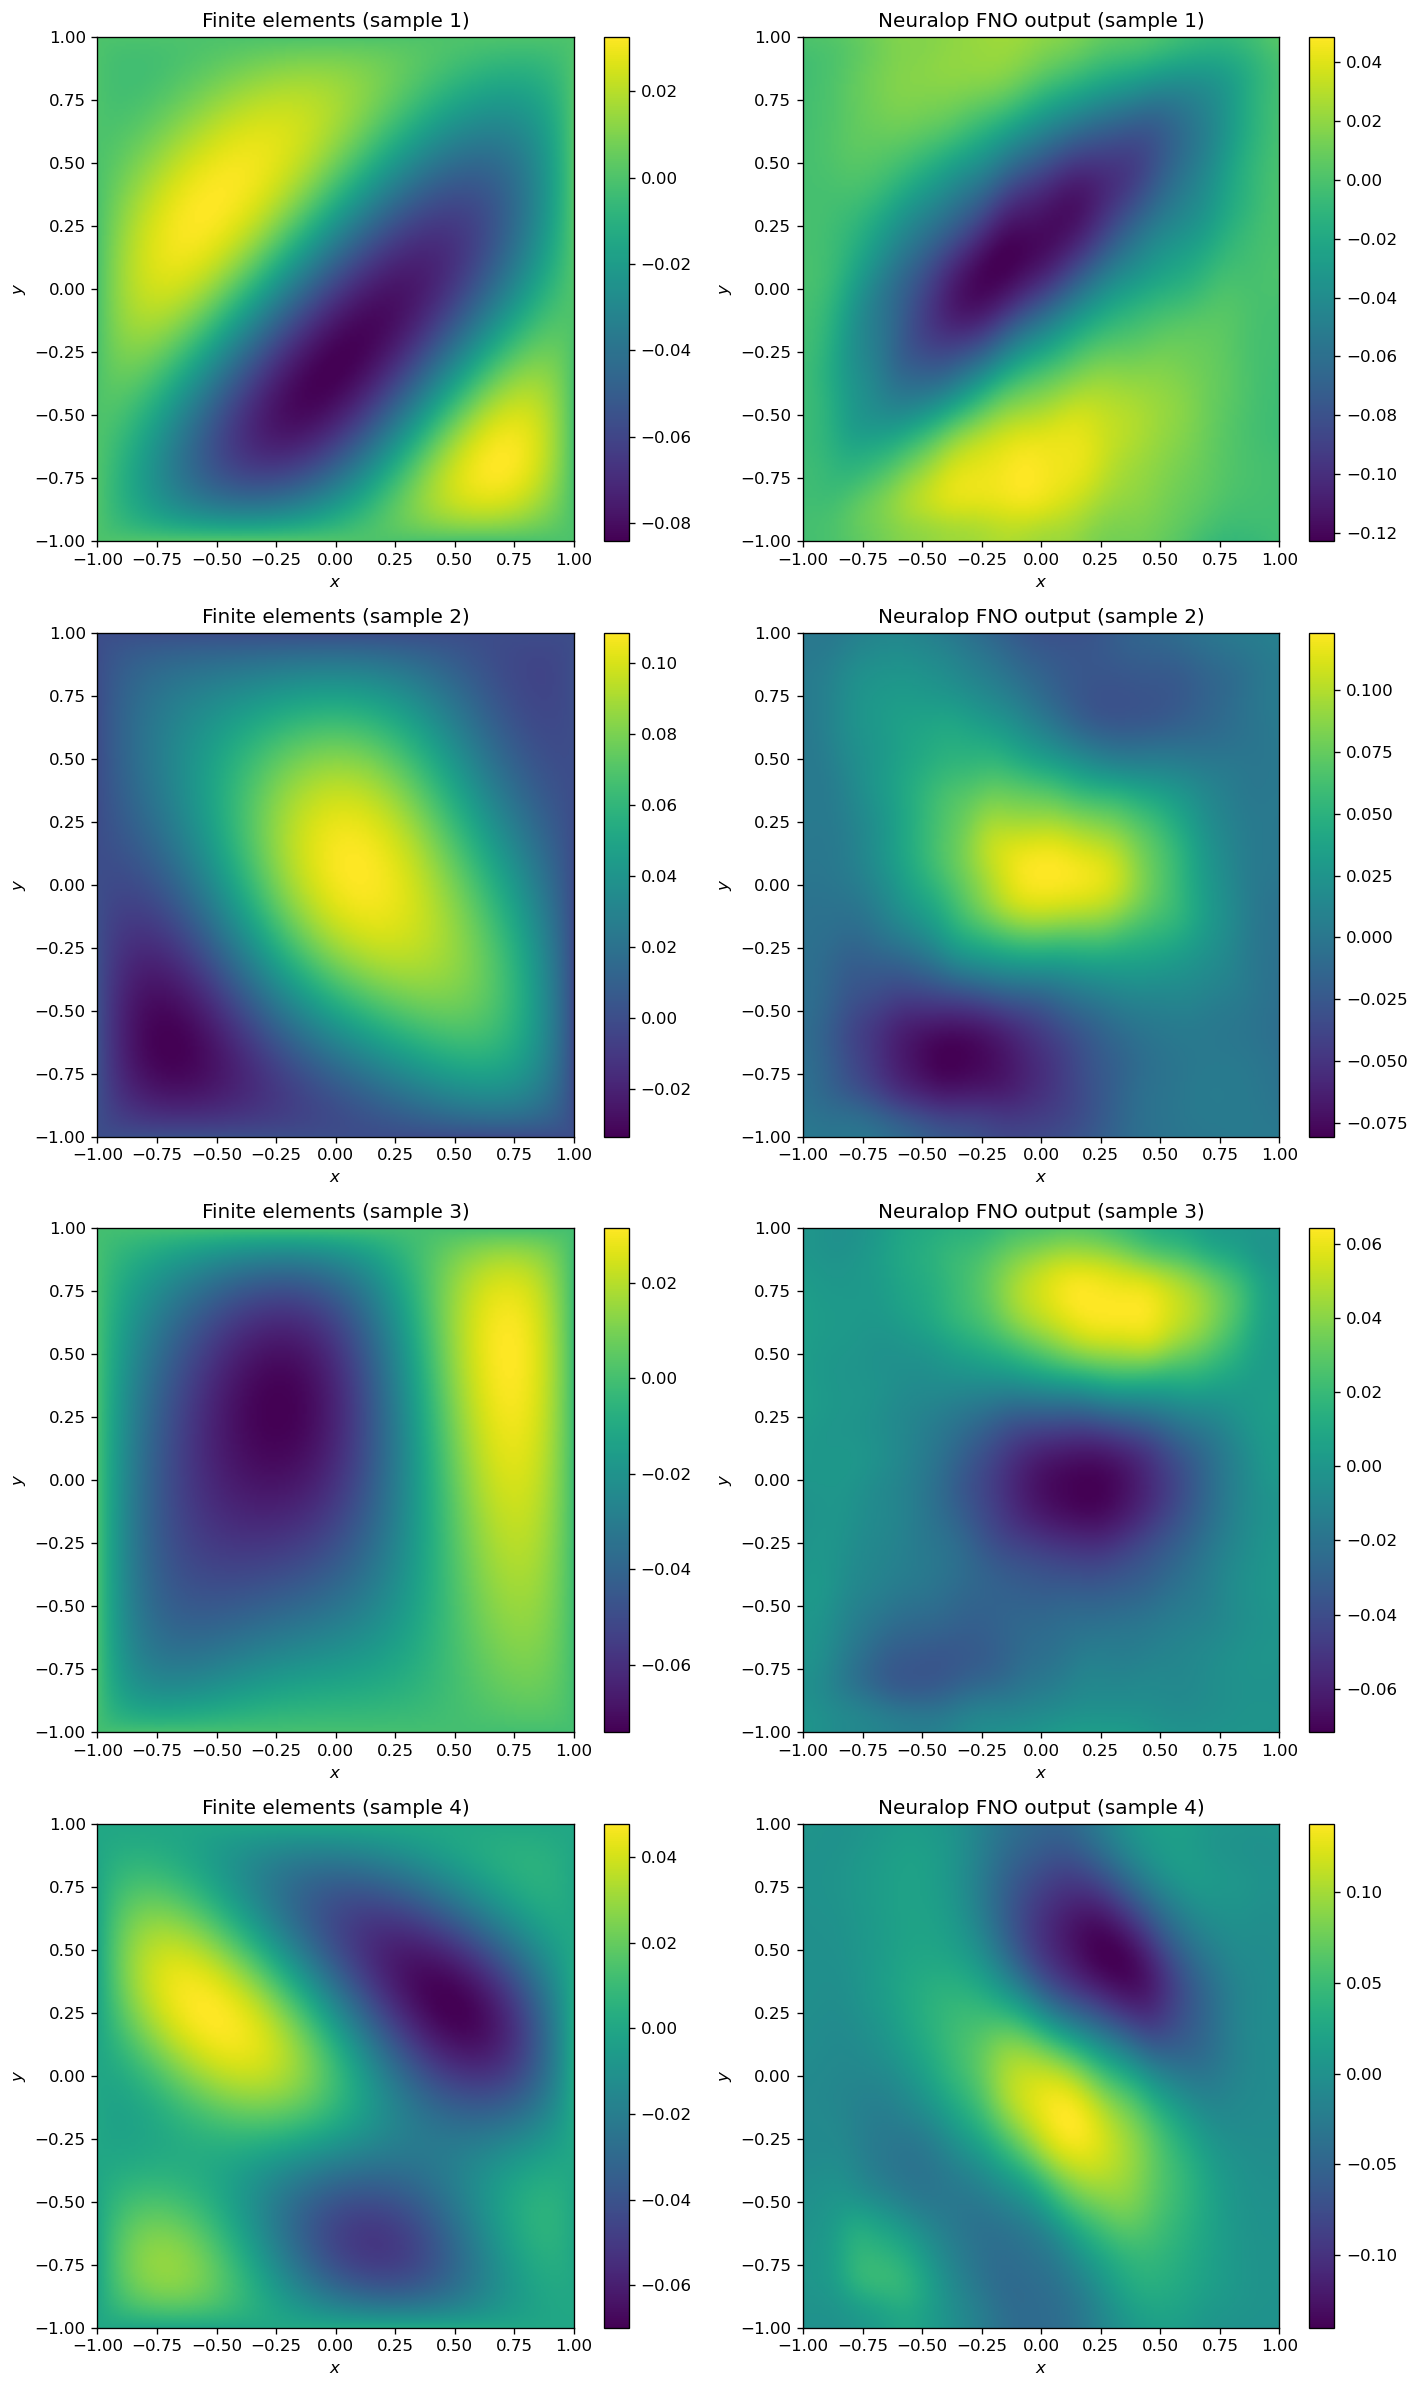

In [7]:
# now test visually on 4 randomly generated functions

x = np.linspace(-1, 1, 200)
y = np.linspace(-1, 1, 200)
mymesh = Mesh(x, y, verbose=True)
mymesh.build_mass_matrix()
mymesh.build_stiffness_matrix()

X, Y = np.meshgrid(x, y, indexing="ij")
diri = lambda x, y: 0

model.eval()

N_test = 4
fig, axes = plt.subplots(N_test, 2, figsize=(12, 5 * N_test), dpi=120)

for i in range(N_test):
    func = generate_source_function()

    res_finite_elements = mymesh.run_simulation_poisson_dirichlet(func, diri)

    # build (1, 3, H, W) input: channels = f, x, y -- matches training data order
    F = func(X, Y)
    model_input = np.stack([F, X, Y], axis=0)  # (3, H, W)
    model_input = torch.from_numpy(model_input).float().unsqueeze(0).to(device)  # (1, 3, H, W)

    with torch.no_grad():
        result_fno = model(model_input).squeeze(0).squeeze(0).cpu().numpy()  # double squeeze: from (1, 1, H, W) to (H, W)

    im0 = axes[i, 0].imshow(res_finite_elements, cmap='viridis', origin='lower', aspect='auto', extent=[x.min(), x.max(), y.min(), y.max()])
    axes[i, 0].set_title(f'Finite elements (sample {i+1})')
    axes[i, 0].set_xlabel('$x$')
    axes[i, 0].set_ylabel('$y$')
    fig.colorbar(im0, ax=axes[i, 0])

    im1 = axes[i, 1].imshow(result_fno, cmap='viridis', origin='lower', aspect='auto', extent=[x.min(), x.max(), y.min(), y.max()])
    axes[i, 1].set_title(f'Neuralop FNO output (sample {i+1})')
    axes[i, 1].set_xlabel('$x$')
    axes[i, 1].set_ylabel('$y$')
    fig.colorbar(im1, ax=axes[i, 1])

plt.tight_layout()
plt.show()

Mass matrix initialization completed
Stiffness matrix initialization completed


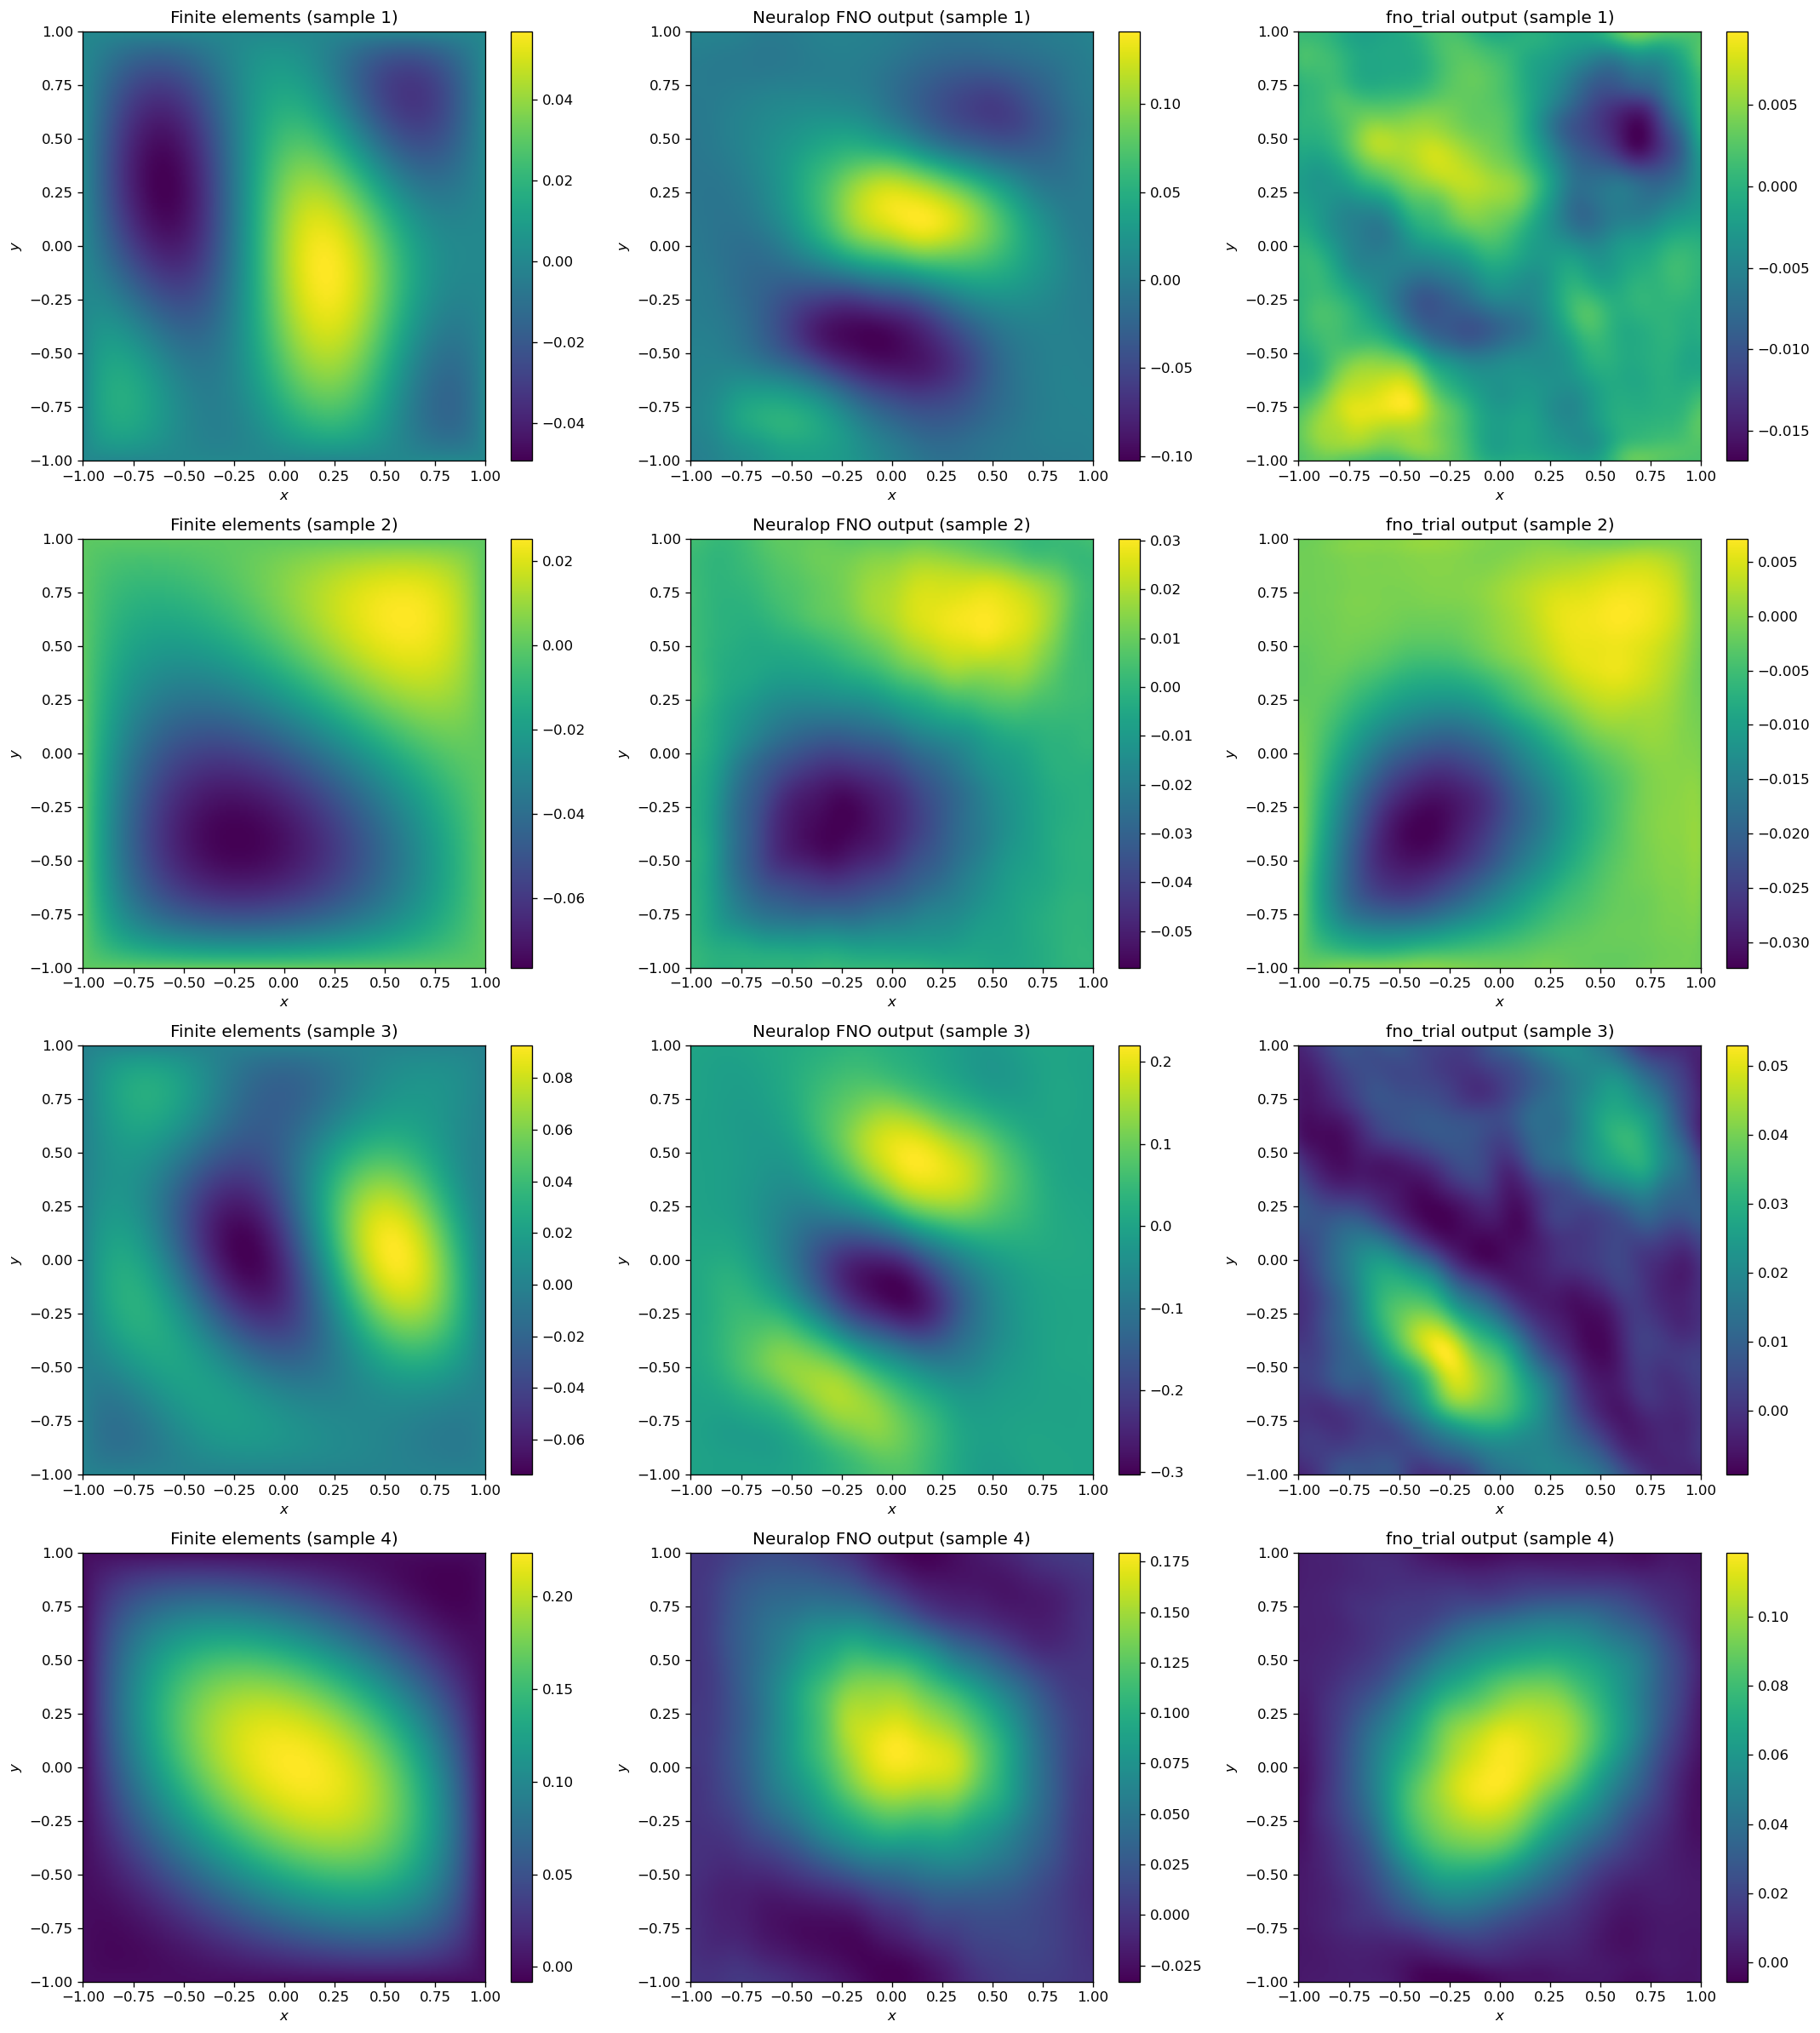

In [8]:
# now put the outputs of both models side-by-side, together with the finite element reference solution

x = np.linspace(-1, 1, 200)
y = np.linspace(-1, 1, 200)
mymesh = Mesh(x, y, verbose=True)
mymesh.build_mass_matrix()
mymesh.build_stiffness_matrix()

X, Y = np.meshgrid(x, y, indexing="ij")
diri = lambda x, y: 0

model.eval()

N_test = 4
fig, axes = plt.subplots(N_test, 3, figsize=(18, 5 * N_test), dpi=120)

for i in range(N_test):
    func = generate_source_function()

    res_finite_elements = mymesh.run_simulation_poisson_dirichlet(func, diri)

    F = func(X, Y)
    model_input = np.stack([F, X, Y], axis=0)  # (3, H, W)
    model_input = torch.from_numpy(model_input).float().unsqueeze(0).to(device)  # (1, 3, H, W)

    with torch.no_grad():
        result_fno = model(model_input).squeeze(0).squeeze(0).cpu().numpy()  # (1,1,H,W) -> (H,W)

    result_fno_trial = fno_trial.map_function_to_output_at_points(func, X, Y)

    # prepare the plot
    im0 = axes[i, 0].imshow(res_finite_elements, cmap='viridis', origin='lower', aspect='auto',
                             extent=[x.min(), x.max(), y.min(), y.max()])
    axes[i, 0].set_title(f'Finite elements (sample {i+1})')
    axes[i, 0].set_xlabel('$x$')
    axes[i, 0].set_ylabel('$y$')
    fig.colorbar(im0, ax=axes[i, 0])

    im1 = axes[i, 1].imshow(result_fno, cmap='viridis', origin='lower', aspect='auto',
                             extent=[x.min(), x.max(), y.min(), y.max()])
    axes[i, 1].set_title(f'Neuralop FNO output (sample {i+1})')
    axes[i, 1].set_xlabel('$x$')
    axes[i, 1].set_ylabel('$y$')
    fig.colorbar(im1, ax=axes[i, 1])

    im2 = axes[i, 2].imshow(result_fno_trial, cmap='viridis', origin='lower', aspect='auto',
                             extent=[x.min(), x.max(), y.min(), y.max()])
    axes[i, 2].set_title(f'fno_trial output (sample {i+1})')
    axes[i, 2].set_xlabel('$x$')
    axes[i, 2].set_ylabel('$y$')
    fig.colorbar(im2, ax=axes[i, 2])

plt.tight_layout()
plt.show()

**Comments**

Both models were trained on a training dataset of 4000 functions (eval dataset 1000 functions)

Using the `neuraloperator` library, the steps are much slower than with my model, for a training dataset of the same size. Probably I should optimize the way I call the neuraloperator library ?

note that n_modes (16, 16) on neuraloperator corresponds to (8,8) on my model (different way of counting)

still, with the same effective number of nmodes (16 in the neuralop model) the neuralop model still produces smoother results. 

Using the h1 loss (albeit coarsely implemented) vs the MSE loss reduces high-frequency noise in the predictions.

**MY MODEL STILL NEEDS IMPROVING**




# TO DO

- use same scheduler on both models: 

        self.optimizer = AdamW(self.parameters(), lr=lr, weight_decay=1e-4)
        self.scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(self.optimizer, T_max=30) # CosineAnnealing: smooth decay of the learning rate

    gives nans on my model, for some reason that I still need to understand
- optimize hyperparameters for best training performance (avoiding overfitting)
- try with h1 loss directly from the `neuraloperator` libray, to see what it gives once it is used in thy FNO model
- in my model, try changing self.channel_mixing to a per-channel affine